#**Aim**

Aim of the coursework is to develop a machine learning system that takes as input imaging brain data, demographic data and cognitive test data and is able to stage the patient into 6 categories: Cognitive normal, Significant Memory Concern, Early mild cognitive impairment, Mild cognitive impairment, Late mild cognitive impairment, Alzheimer's disease.
A different grouping into 3 categories might be possible and can be alternatively explored: Cognitive normal, Cognitive impairment (Significant Memory Concern, Early mild cognitive impairment, Mild cognitive impairment, Late mild cognitive impairment), Alzheimer's disease.


#**Data**

A subset of the Alzheimer’s Disease Neuroimaging Initiative* (ADNI) database (adni.loni.usc.edu) data preprocessed for the TADPOLE Grand Challenge are made available foe the coursework.
The available ADNI data contains baseline imaging, clinical, and genetic data for over 1737 patients originating from tow studies (ADNI1, ADNI2)

The excel data contains three sheets:
⦁	Diagnosis target: the RID column contains the subject identifier;
-the Test_Data column divides the data into the training set (0) and test set (1), so to have the possibility to consistently compare performance across different methodologies and reports;
-the Diagnosis column contains the 6 categories to be predicted
⦁	Cognitive scores:
-the first two column are the same as for the “Diagnosis” sheet,
-columns C-J contains the value for different cognitive scores that can be used as input of the predictive model
⦁	Data:  
-the first two column are the same as for the “Diagnosis” sheet,
-the other columns contain demographic information (columns C-H)
-the presence of a high risk genetic alleles (column I)  and
-the volume and thickness of different brain regions obtained from MRI data

All data in the “Cognitive scores” and “Data sheets” can be used as input data.

The test set in the file has to be used for the final evaluation of the model performance

#**Performance metrics**

Report as performance metrics at least accuracy, precision and recall for each class on the test data, and the confusion matrix on the test data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, f1_score, recall_score
from sklearn.impute import SimpleImputer
from sklearn.metrics import precision_recall_curve, roc_curve, auc, roc_auc_score
from itertools import cycle

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
diagnosis_data = pd.read_excel('/content/drive/MyDrive/AssignmentML_Alzheimer_using_BrainMRI/CSI_7_MAL_2324_CW_resit_data.xlsx', sheet_name='Diagnosis target')
cognitive_scores_data = pd.read_excel('/content/drive/MyDrive/AssignmentML_Alzheimer_using_BrainMRI/CSI_7_MAL_2324_CW_resit_data.xlsx', sheet_name='Cognitive score')
demographic_data = pd.read_excel('/content/drive/MyDrive/AssignmentML_Alzheimer_using_BrainMRI/CSI_7_MAL_2324_CW_resit_data.xlsx', sheet_name='Data')

In [4]:
diagnosis_data.head()

,RID,Test_data,Diagnosis,FDG_PET
0,2,0,CN,1.36926
1,3,0,AD,1.09079
2,4,1,LMCI,NaN
3,5,0,CN,1.29799
4,6,0,LMCI,NaN


<ipython-input-5-ab59a622133e>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(diagnosis_data, x='FDG_PET', y='Diagnosis', inner='box', palette='Dark2')


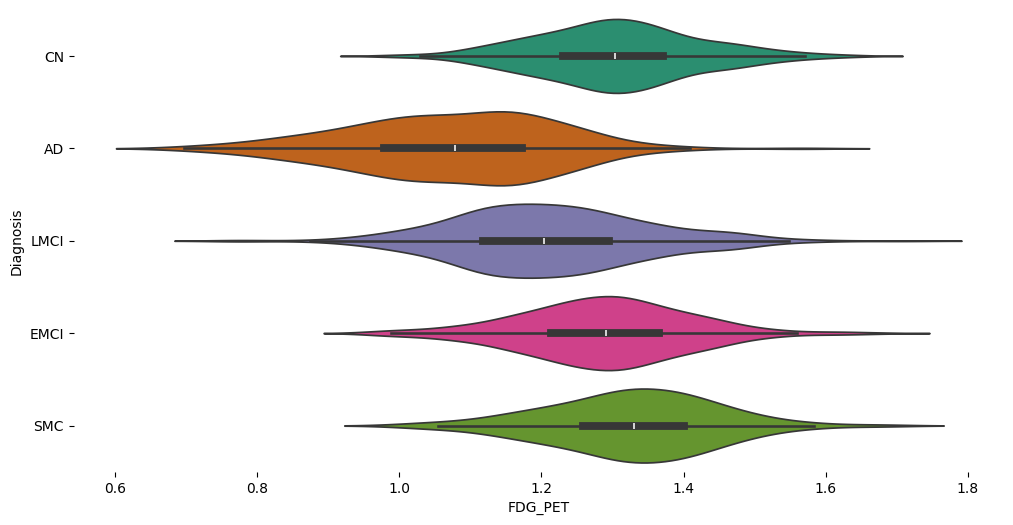

In [5]:
# @title Diagnosis vs FDG_PET

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(diagnosis_data['Diagnosis'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(diagnosis_data, x='FDG_PET', y='Diagnosis', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [6]:
cognitive_scores_data.head()

,RID,Test_data,CDRSB,ADAS11,ADAS13,MMSE,RAVLT_immediate,RAVLT_learning,RAVLT_forgetting,RAVLT_perc_forgetting
0,2,0,0.0,10.67,18.67,28,44.0,4.0,6.0,54.5455
1,3,0,4.5,22.00,31.00,20,22.0,1.0,4.0,100.0000
2,4,1,1.0,14.33,21.33,27,37.0,7.0,4.0,36.3636
3,5,0,0.0,8.67,14.67,29,37.0,4.0,4.0,44.4444
4,6,0,0.5,18.67,25.67,25,30.0,1.0,5.0,83.3333


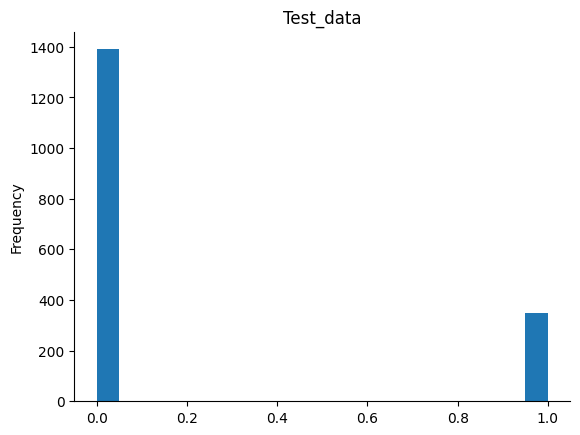

In [ ]:
# @title Test_data

from matplotlib import pyplot as plt
cognitive_scores_data['Test_data'].plot(kind='hist', bins=20, title='Test_data')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
demographic_data.head()

,RID,Test_data,Age,Gender,Year_education,Ethnicity,Race,Marital_status,High_risk_ApoE4,Ventricles,...,Cortical Thickness Standard Deviation of RightLingual,Volume (Cortical Parcellation) of RightMedialOrbitofrontal,Surface Area of RightMedialOrbitofrontal,Cortical Thickness Average of RightMedialOrbitofrontal,Cortical Thickness Standard Deviation of RightMedialOrbitofrontal,Volume (Cortical Parcellation) of RightMiddleTemporal,Surface Area of RightMiddleTemporal,Cortical Thickness Average of RightMiddleTemporal,Cortical Thickness Standard Deviation of RightMiddleTemporal,Volume (WM Parcellation) of FourthVentricle
0,2,0,74.3,Male,16,Not Hisp/Latino,White,Married,0.0,118233.0,...,0.694,3835,1622,2.077,0.746,15683,4272,3.028,0.649,4396
1,3,0,81.3,Male,18,Not Hisp/Latino,White,Married,1.0,84599.0,...,0.591,3681,1734,1.942,0.696,10387,3316,2.545,0.686,3304
2,4,1,67.5,Male,10,Hisp/Latino,White,Married,0.0,39605.0,...,0.588,4060,1728,2.18,0.607,11156,3598,2.67,0.631,1338
3,5,0,73.7,Male,16,Not Hisp/Latino,White,Married,0.0,34062.0,...,0.628,5180,1868,2.543,0.709,11579,3387,2.911,0.66,1623
4,6,0,80.4,Female,13,Not Hisp/Latino,White,Married,0.0,39826.0,...,0.631,3078,1241,2.141,0.701,9641,2781,2.9,0.727,1035


**Check Missing Values**

In [7]:
diagnosis_data.isnull().sum()

RID            0
Test_data      0
Diagnosis      0
FDG_PET      434
dtype: int64

In [8]:
cognitive_scores_data.isnull().sum()

RID                       0
Test_data                 0
CDRSB                     0
ADAS11                    5
ADAS13                   14
MMSE                      0
RAVLT_immediate           6
RAVLT_learning            6
RAVLT_forgetting          6
RAVLT_perc_forgetting    11
dtype: int64

In [9]:
demographic_data.isnull().sum()

RID                                                             0
Test_data                                                       0
Age                                                             0
Gender                                                          0
Year_education                                                  0
                                                               ..
Volume (Cortical Parcellation) of RightMiddleTemporal           0
Surface Area of RightMiddleTemporal                             0
Cortical Thickness Average of RightMiddleTemporal               0
Cortical Thickness Standard Deviation of RightMiddleTemporal    0
Volume (WM Parcellation) of FourthVentricle                     0
Length: 361, dtype: int64

**Merge data on the basis of 'RID' and 'Test_data'**


In [10]:
merged_data = pd.merge(diagnosis_data, cognitive_scores_data, on=['RID', 'Test_data'], how='inner')
merged_data = pd.merge(merged_data, demographic_data, on=['RID', 'Test_data'], how='inner')

In [11]:
merged_data.head()

,RID,Test_data,Diagnosis,FDG_PET,CDRSB,ADAS11,ADAS13,MMSE,RAVLT_immediate,RAVLT_learning,...,Cortical Thickness Standard Deviation of RightLingual,Volume (Cortical Parcellation) of RightMedialOrbitofrontal,Surface Area of RightMedialOrbitofrontal,Cortical Thickness Average of RightMedialOrbitofrontal,Cortical Thickness Standard Deviation of RightMedialOrbitofrontal,Volume (Cortical Parcellation) of RightMiddleTemporal,Surface Area of RightMiddleTemporal,Cortical Thickness Average of RightMiddleTemporal,Cortical Thickness Standard Deviation of RightMiddleTemporal,Volume (WM Parcellation) of FourthVentricle
0,2,0,CN,1.36926,0.0,10.67,18.67,28,44.0,4.0,...,0.694,3835,1622,2.077,0.746,15683,4272,3.028,0.649,4396
1,3,0,AD,1.09079,4.5,22.00,31.00,20,22.0,1.0,...,0.591,3681,1734,1.942,0.696,10387,3316,2.545,0.686,3304
2,4,1,LMCI,NaN,1.0,14.33,21.33,27,37.0,7.0,...,0.588,4060,1728,2.18,0.607,11156,3598,2.67,0.631,1338
3,5,0,CN,1.29799,0.0,8.67,14.67,29,37.0,4.0,...,0.628,5180,1868,2.543,0.709,11579,3387,2.911,0.66,1623
4,6,0,LMCI,NaN,0.5,18.67,25.67,25,30.0,1.0,...,0.631,3078,1241,2.141,0.701,9641,2781,2.9,0.727,1035


#**Data Preprocessing**

In [12]:
merged_data.isnull().sum()

RID                                                               0
Test_data                                                         0
Diagnosis                                                         0
FDG_PET                                                         434
CDRSB                                                             0
                                                               ... 
Volume (Cortical Parcellation) of RightMiddleTemporal             0
Surface Area of RightMiddleTemporal                               0
Cortical Thickness Average of RightMiddleTemporal                 0
Cortical Thickness Standard Deviation of RightMiddleTemporal      0
Volume (WM Parcellation) of FourthVentricle                       0
Length: 371, dtype: int64

In [13]:
# Handling missing values
for column in merged_data.columns:
    if merged_data[column].isnull().any():
       if merged_data[column].dtype == 'float64' or merged_data[column].dtype == 'int64':
           merged_data[column].fillna(merged_data[column].mean(), inplace=True)

In [14]:
merged_data.isnull().sum()

RID                                                             0
Test_data                                                       0
Diagnosis                                                       0
FDG_PET                                                         0
CDRSB                                                           0
                                                               ..
Volume (Cortical Parcellation) of RightMiddleTemporal           0
Surface Area of RightMiddleTemporal                             0
Cortical Thickness Average of RightMiddleTemporal               0
Cortical Thickness Standard Deviation of RightMiddleTemporal    0
Volume (WM Parcellation) of FourthVentricle                     0
Length: 371, dtype: int64

In [15]:
merged_data.count(axis='columns')

0       371
1       371
2       371
3       371
4       371
       ... 
1732    371
1733    371
1734    370
1735    371
1736    371
Length: 1737, dtype: int64

In [16]:
merged_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1737 entries, 0 to 1736
Columns: 371 entries, RID to Volume (WM Parcellation) of FourthVentricle
dtypes: float64(17), int64(4), object(350)
memory usage: 4.9+ MB


In [17]:
merged_data.shape

(1737, 371)

In [ ]:
merged_data.describe()

,RID,Test_data,FDG_PET,CDRSB,ADAS11,ADAS13,MMSE,RAVLT_immediate,RAVLT_learning,RAVLT_forgetting,...,Age,Year_education,High_risk_ApoE4,Ventricles,Hippocampus,WholeBrain,Entorhinal,Fusiform,MidTemp,Intra cranial volume
count,1737.000000,1737.000000,1737.000000,1737.000000,1737.000000,1737.000000,1737.000000,1737.000000,1737.000000,1737.000000,...,1737.000000,1737.000000,1737.000000,1737.000000,1737.000000,1.737000e+03,1737.000000,1737.000000,1737.000000,1.737000e+03
mean,2603.533679,0.199770,1.233933,1.639321,10.773672,16.899008,27.173287,35.153091,4.177354,4.328712,...,73.770466,15.905009,0.568116,40283.351662,6788.269980,1.020934e+06,3486.980218,17308.341746,19453.816508,1.531371e+06
std,1926.356831,0.399942,0.133508,1.792005,6.648094,9.545505,2.666661,12.442921,2.729400,2.455592,...,7.196227,2.857334,0.663935,22109.941385,1097.255813,1.098424e+05,716.992873,2530.020613,2836.403312,1.658828e+05
min,2.000000,0.000000,0.697264,0.000000,0.000000,0.000000,18.000000,0.000000,-4.000000,-5.000000,...,54.400000,4.000000,0.000000,5650.000000,2991.000000,6.693640e+05,1426.000000,8991.000000,9375.000000,1.100690e+06
25%,759.000000,0.000000,1.177450,0.000000,6.000000,9.330000,26.000000,26.000000,2.000000,3.000000,...,69.200000,14.000000,0.000000,24473.000000,6124.000000,9.431610e+05,3084.000000,15846.000000,17881.000000,1.411900e+06
50%,2150.000000,0.000000,1.233933,1.000000,9.000000,15.000000,28.000000,34.000000,4.000000,4.000000,...,73.900000,16.000000,0.000000,36764.000000,6788.269980,1.020934e+06,3486.980218,17308.341746,19453.816508,1.518700e+06
75%,4546.000000,0.000000,1.303960,2.500000,14.000000,23.000000,29.000000,44.000000,6.000000,6.000000,...,78.900000,18.000000,1.000000,50326.000000,7510.000000,1.093080e+06,3926.000000,18681.000000,21143.000000,1.638690e+06
max,5296.000000,1.000000,1.707170,10.000000,42.670000,54.670000,30.000000,71.000000,12.000000,15.000000,...,91.400000,20.000000,2.000000,145115.000000,10769.000000,1.486040e+06,5896.000000,29950.000000,32189.000000,2.110290e+06


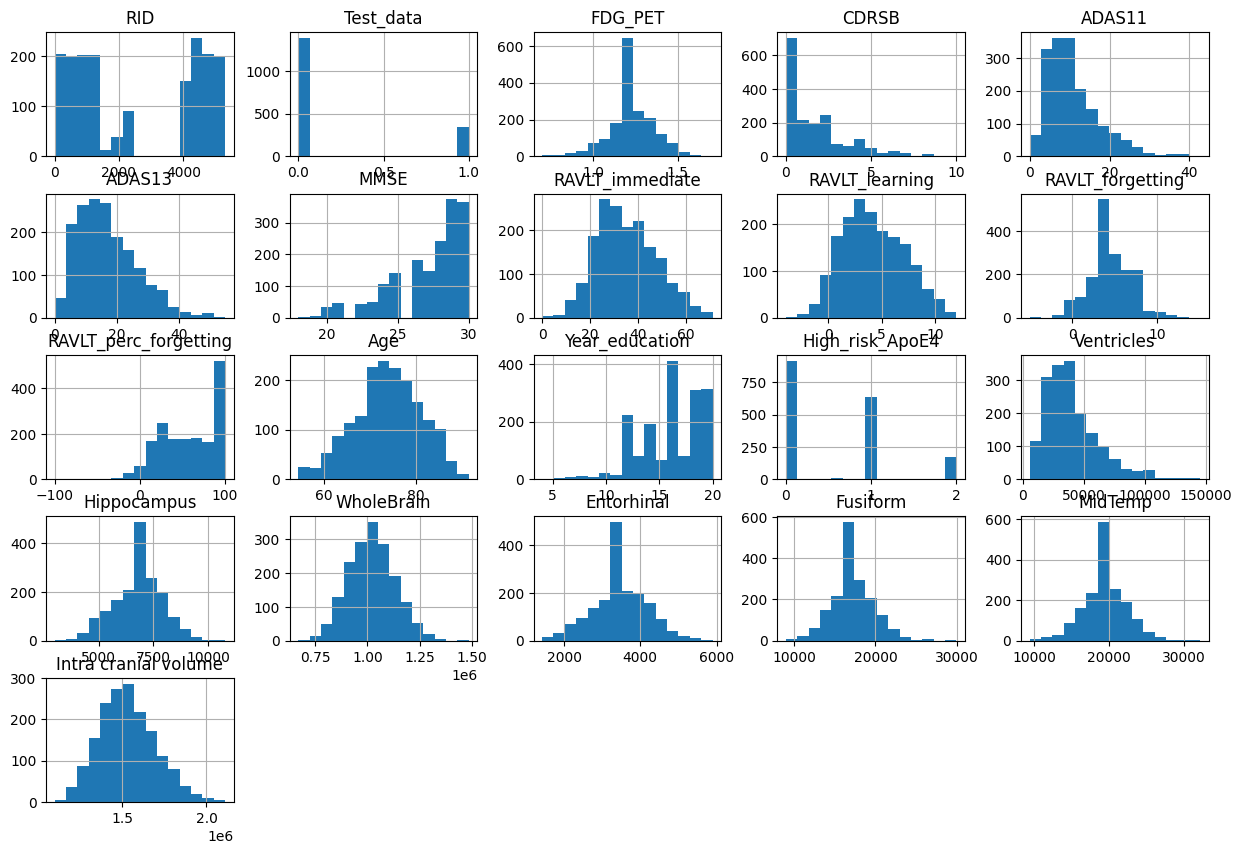

In [ ]:
merged_data.hist(bins=15, figsize=(15, 10))
plt.show()

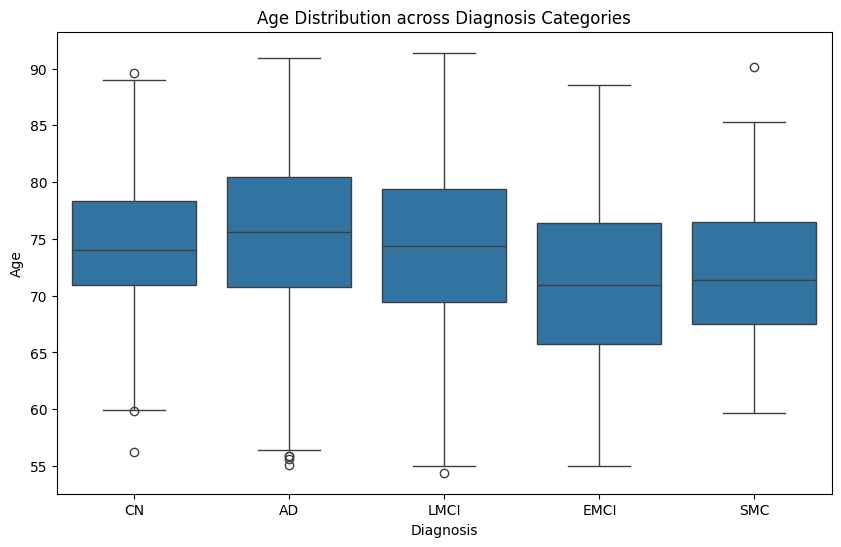

In [18]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Diagnosis', y='Age', data=merged_data)
plt.title('Age Distribution across Diagnosis Categories')
plt.show()

<ipython-input-66-ad96bc3aa8bf>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = merged_data.corr()


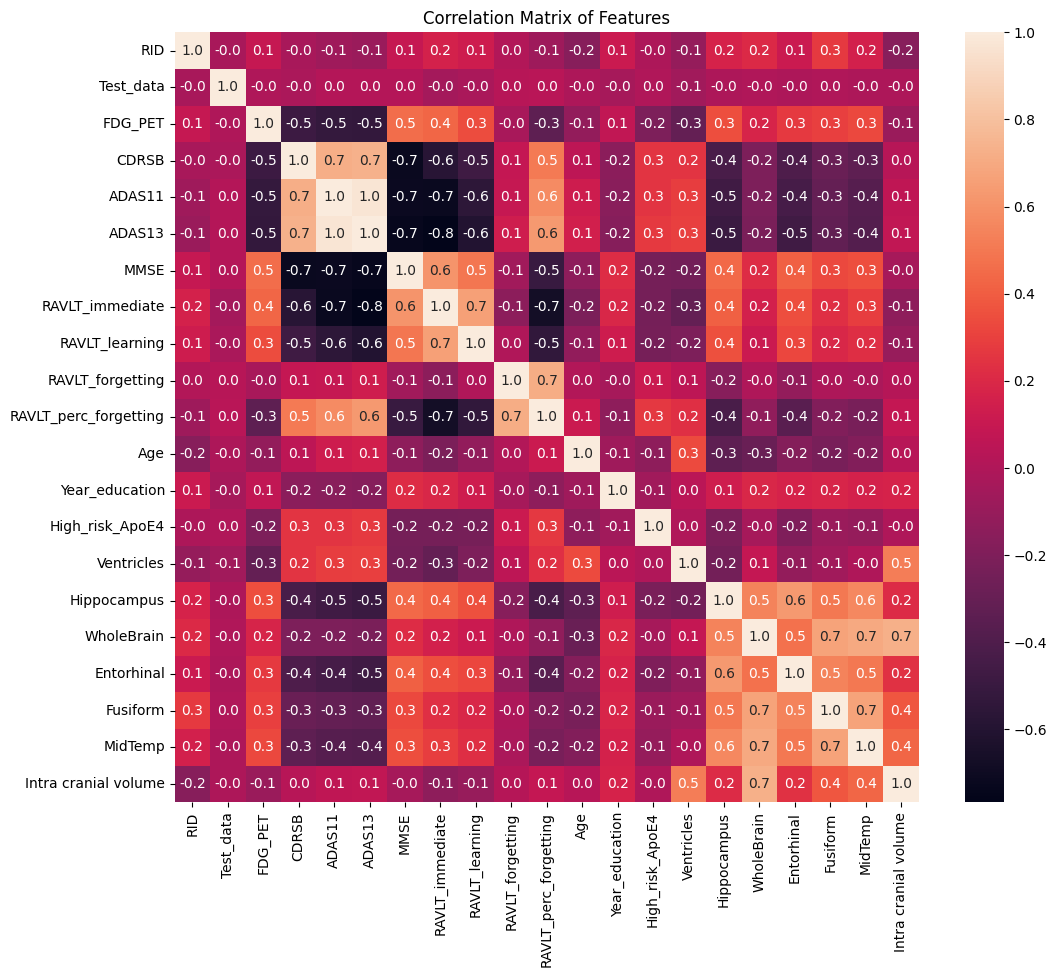

In [ ]:
plt.figure(figsize=(12, 10))
correlation_matrix = merged_data.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".1f")
plt.title('Correlation Matrix of Features')
plt.show()

**Seperate Data**

In [ ]:
#test_data = merged_data[merged_data['Test_data'] == 1]

In [ ]:
#train_data = train_data.drop(columns=['Test_data'])
#test_data = test_data.drop(columns=['Test_data'])

In [19]:
# preprocessing steps numerical and categorical data
categorical_features = merged_data.select_dtypes(include=['object']).columns
numerical_features = merged_data.select_dtypes(exclude=['object']).columns

In [20]:
# Convert categorical columns to string for data consistency
merged_data[categorical_features] = merged_data[categorical_features].astype(str)

In [21]:
train_data = merged_data[merged_data['Test_data'] == 0]

In [22]:
test_data = merged_data[merged_data['Test_data'] == 1]

In [23]:
train_data = train_data.drop(columns=['Test_data'])
test_data = test_data.drop(columns=['Test_data'])

In [24]:
X_train = train_data.drop(columns=['RID', 'Diagnosis'])
X_test = test_data.drop(columns=['RID', 'Diagnosis'])
y_train = train_data['Diagnosis']
y_test = test_data['Diagnosis']

In [25]:
# Encoding the target variable to handle multi-class classification
y_train, _ = pd.factorize(y_train)
y_test, _ = pd.factorize(y_test)

In [26]:
# Creating pipelines for the preprocessing steps
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])

In [27]:
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

In [28]:
#X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=X['Test_data'])

In [29]:
# Re-training the model with the corrected data types
model_pipeline.fit(X_train, y_train)

ValueError: A given column is not a column of the dataframe

In [ ]:
y_pred = model_pipeline.predict(X_test)

In [ ]:
# Recalculating performance metrics with the corrected data
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
conf_matrix = confusion_matrix(y_test, y_pred)

In [ ]:
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

In [ ]:
# Plotting the confusion matrix for the 6-category classification
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=_[1:], yticklabels=_[1:])
plt.title('Confusion Matrix for 6-Category Classification')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

#**Hyperparameter Tuning**

In [ ]:
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

# Set up the parameter distribution
param_dist = {
    'classifier__n_estimators': randint(50, 500),
    'classifier__max_depth': randint(1, 20)
}

# Adjust your pipeline if necessary to include the RandomForestClassifier
model_pipeline.steps[-1] = ('classifier', RandomForestClassifier())

# Create the RandomizedSearchCV object
rand_search = RandomizedSearchCV(
    model_pipeline,
    param_distributions=param_dist,
    n_iter=5,
    cv=5,
    scoring='accuracy',
    error_score='raise',
    verbose=1 )

In [ ]:
rand_search.fit(X_train, y_train)

In [ ]:
# Create a variable for the best model
best_rf = rand_search.best_estimator_

# Print the best hyperparameters
print('Best hyperparameters:',  rand_search.best_params_)

In [ ]:
# Print the best parameters and the corresponding score
print("Best parameters found: ", rand_search.best_params_)
print("Best score found: ", rand_search.best_score_)

In [ ]:
# Use the best estimator to predict on the test data
best_model = rand_search.best_estimator_
y_pred = best_model.predict(X_test)

In [ ]:
# Calculate and print performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
conf_matrix = confusion_matrix(y_test, y_pred)

In [ ]:
print("Accuracy: ", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Update your RandomForestClassifier to handle class weight
rf = RandomForestClassifier(class_weight='balanced')

# Update the pipeline step for the classifier
model_pipeline.steps[-1] = ('classifier', rf)

# Run RandomizedSearchCV as before
rand_search.fit(X_train, y_train)

# Get the best estimator and make predictions as before
best_model = rand_search.best_estimator_
y_pred = best_model.predict(X_test)

# Calculate performance metrics and print them
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"Accuracy: {accuracy}\nPrecision: {precision}\nRecall: {recall}\nF1-score: {f1}")


#**xgboost Sample Code**

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(eval_metric='mlogloss'))
])

#parameter distribution
param_dist = {
    'classifier__n_estimators': randint(50, 500),
    'classifier__max_depth': randint(1, 10),
    'classifier__learning_rate': uniform(0.01, 0.3)
}

rand_search_xgb = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=param_dist,
    n_iter=5,
    cv=5,
    scoring='accuracy',
    error_score='raise',
    verbose=1
)

rand_search_xgb.fit(X_train, y_train)

best_xgb_model = rand_search_xgb.best_estimator_

y_pred_xgb = best_xgb_model.predict(X_test)

In [ ]:
# Calculate performance metrics and print them
accuracy = accuracy_score(y_test, y_pred_xgb)
precision = precision_score(y_test, y_pred_xgb, average='weighted')
recall = recall_score(y_test, y_pred_xgb, average='weighted')
f1 = f1_score(y_test, y_pred_xgb, average='weighted')
print(f"Accuracy: {accuracy}\nPrecision: {precision}\nRecall: {recall}\nF1-score: {f1}")